In [55]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import r2_score
from scipy import stats
from scipy.special import inv_boxcox


In [56]:
data = pd.read_excel('Forecast_demand_data.xlsx', sheet_name = 'Demand')

In [57]:
data = data.T

# Resetting the index so the first row becomes the header
data.reset_index(inplace=True)
new_header = data.iloc[0]  # Grab the first row for the header
data = data[1:]  # Take the data less the header row
data.columns = new_header  # Set the header row as the df header

data

,Antigen,Measles,Mumps,Rubella,Diphtheria,Tetanus,Pertussis,Hepatitis_B,Hib,Polio,HPV,Rotavirus,PCV
1,2000,110184355.0,14895547.0,31604096.0,420502653.0,498662082.0,348814438.0,53534395.0,10972631.0,301694795.29,0.0,0.0,0.0
2,2001,114307142.0,15916937.0,32625821.0,430423519.0,510178451.0,359116487.0,65035577.0,14749478.0,325020669.986447,0.0,0.0,0.0
3,2002,112328294.0,16440302.0,33061541.0,422659120.0,505231192.0,352212313.0,142552460.0,24848263.0,330516182.045092,0.0,0.0,0.0
4,2003,120587958.0,17051794.0,33964093.0,442151969.0,527899341.0,369903178.0,176861989.0,29092822.0,345227358.555789,0.0,0.0,0.0
5,2004,129895993.0,25753121.0,43743914.0,485071830.0,573895332.0,396047209.0,210343448.0,41843072.0,370122959.802895,0.0,0.0,0.0
6,2005,148890003.0,26516485.0,58741080.0,506451337.0,597432163.0,419499805.0,242350719.0,51014896.0,379929193.846184,0.0,0.0,0.0
7,2006,155481077.0,28053836.0,64064132.0,487823186.0,581257411.0,412793682.0,250960256.0,52364656.0,377116086.46,0.0,3029896.0,0.0
8,2007,159027889.0,27963867.0,63602346.0,483645320.0,581750577.0,410544078.0,265949497.0,79540844.0,383242198.285789,0.0,7758596.0,0.0
9,2008,180942619.0,39454389.0,60547652.0,470892419.0,571970865.0,412596277.0,283972650.0,96781659.0,383131959.955263,9437.0,1545856.0,6301.0
10,2009,173746059.0,41213109.0,63566234.0,479676741.0,584259538.0,423562197.0,299712635.0,157581638.0,397706978.195789,15033.0,4340800.0,1716888.0


In [58]:
data.iloc[13:]

,Antigen,Measles,Mumps,Rubella,Diphtheria,Tetanus,Pertussis,Hepatitis_B,Hib,Polio,HPV,Rotavirus,PCV
14,2013,184600677.0,22105642.0,37190191.0,358960052.0,523242808.0,328701755.0,307013342.0,154141277.0,354511503.711447,181341.0,21235066.0,41170015.0
15,2014,169922012.0,19837777.0,43940031.0,354880969.0,528432014.0,323938145.0,304655315.0,175806595.0,355186102.645603,349925.0,35141119.0,66222136.0
16,2015,341329845.0,26434485.0,128302869.0,362257229.0,540142924.0,325441283.0,306586598.0,234434326.0,371591674.639097,514654.0,44497769.0,89756384.0
17,2016,307378677.0,20737739.0,110243636.0,402799889.0,552631403.0,326230496.0,310915297.0,261706481.0,459148209.502123,1545657.0,55341924.0,107603981.0
18,2017,380696579.0,20303126.0,186643246.0,429658592.0,615744020.0,333387964.0,318821586.0,267997879.0,510749541.409942,2487801.0,66664537.0,127327221.0
19,2018,586313630.0,23934205.0,434104155.0,474101067.0,638869328.0,341894642.0,332337842.0,277236714.0,520616139.799227,6959717.0,93092909.0,136528866.0
20,2019,475240096.0,21792972.0,354218405.0,595266022.0,637765782.0,348615177.0,340059522.0,283780799.0,545892364.245208,10275961.0,126525666.0,145562505.0
21,2020,291360748.0,18694960.0,212986007.0,606971011.0,617489918.0,333074171.0,329290310.0,272465350.0,525681082.767697,12011982.0,142261312.0,141811833.0
22,2021,420097004.0,26052156.0,357331305.0,570550152.0,577730183.0,320662742.0,312284565.0,259536228.0,522182008.892054,18988210.0,142479003.0,160800233.0
23,2022,358616887.0,26626399.0,254011421.0,619539916.0,626350955.0,347414024.0,343008157.0,282777104.0,582182282.261939,18779835.0,166422083.0,186996097.0


In [59]:
def safe_log(x, p):
    """
    Applies a transformation to a given pandas Series, leaving zero values unchanged and handling non-numeric types.

    Parameters:
    - x: A pandas Series.
    - p: Type of transformation ('log', 'log10', or any numeric value for power transformation).

    Returns:
    - A transformed pandas Series where zeros remain zeros.
    """
    # Convert x to a numeric type, coercing errors to NaN (which won't affect zeros)
    x_numeric = pd.to_numeric(x, errors='coerce')
    
    # Creating a mask for non-zero values
    mask = x_numeric != 0

    # Copy the original numeric series to preserve zeros and NaNs
    result = x_numeric.copy()

    # Apply transformations only to non-zero values
    if p == 'log':
        result[mask] = np.log(x_numeric[mask])
    elif p == 'log10':
        result[mask] = np.log10(x_numeric[mask])
    else:
        # For power transformations, assuming 'p' is a number
        result[mask] = np.power(x_numeric[mask], p)

    return result



    

def safe_return(x, p):
    """
    Reverses the inverse transformation for a given pandas Series.

    Parameters:
    - x: A pandas Series with values that have been log-transformed.
    - p: type of transformation

    Returns:
    - A pandas Series with the original values before the transformation.
    """
    if p == 'log':
        return np.exp(x)
    elif p == 'log10':
        return 10 ** x
    else:
        return np.power(x,1/p)


# def safe_log(x, p):
#     """
#     Reverses the transformation for a given pandas Series.

#     Parameters:
#     - x: A pandas Series.
#     - p: type of transformation

#     Returns:
#     - A transformed pandas Series.
#     """
#     if p == 'log':
#         return np.log(x)
#     elif p == 'log10':
#         return np.log10(x)
#     else:
#         return np.power(x,p)
    

# def safe_return(x, p):
#     """
#     Reverses the inverse transformation for a given pandas Series.

#     Parameters:
#     - x: A pandas Series with values that have been log-transformed.
#     - p: type of transformation

#     Returns:
#     - A pandas Series with the original values before the transformation.
#     """
#     if p == 'log':
#         return np.exp(x)
#     elif p == 'log10':
#         return 10 ** x
#     else:
#         return np.power(x,1/p)



In [60]:
def remove_leading_zeros(series):
    """
    Removes leading zeros from a pandas Series and returns the trimmed Series.
    """
    # Convert series to boolean where True indicates non-zero values
    non_zero_mask = series != 0
    
    # Find the index of the first non-zero value
    first_non_zero_index = non_zero_mask.idxmax()
    
    # Slice the series from the first non-zero value onwards
    trimmed_series = series.loc[first_non_zero_index:]
    
    return trimmed_series


In [79]:
def process_column_with_forecast(column_data, column_name, p):
    column_data = remove_leading_zeros(column_data).astype(float)
    # column_data = column_data.apply(safe_log)
    # transformed_data, lambda_value = stats.boxcox(column_data)
    # column_data = column_data / 1000000
    column_data = safe_log(column_data, p)
    # print(lambda_value)
    seasonal = False
    model = pm.auto_arima(column_data, 
                          m=1, seasonal=seasonal, d=None, test='adf', 
                          start_p=2, start_q=0, max_p=5, max_q=5, D=None,
                          max_order = 10, information_criterion = 'aic',
                          trace=False, error_action='ignore',  
                          suppress_warnings=True, stepwise=True)
    curr_model = model.order
    model.plot_diagnostics()
    plt.show()
    # plt.savefig(f'figs/{column_name}_diagnostic_plot.png')
    plt.close()

    # Forecasting
    fc, confint = model.predict(n_periods=10, return_conf_int=True)
    fitted_values = model.predict_in_sample()
    # print(fitted_values)

    # Calculating AIC value
    aic_value = model.aic()

    # Creating a DataFrame for the fitted and forecasted values
    fitted_values = safe_return(fitted_values, p)
    fitted_df = pd.DataFrame(fitted_values)
    fitted_df.rename(columns={'predicted_mean': f'{column_name}_fitted'}, inplace=True)
    # fitted_df.rename(columns={0: f'{column_name}_fitted'}, inplace=True)
    # print(fitted_df)
    
    fc = safe_return(fc, p)
    # fc = inv_boxcox(fc, lambda_value)
    fc_df = pd.DataFrame(fc, columns=[f'{column_name}_forecast'])
    
    # confint = inv_boxcox(confint, lambda_value)
    confint = safe_return(confint,p)
    confidence_df = pd.DataFrame(confint, columns=['Lower', 'Upper'])
    
    #testing changing indices
    if isinstance(data[column].index, pd.DatetimeIndex):
        # If your index is datetime, generate new dates that follow the last date of the historical data
        last_date = data[column].index[-1]
        forecast_dates = pd.date_range(start=last_date, periods=len(fc) + 1, freq='M')[1:]  # Adjust 'freq' as needed
    else:
        # For numeric indices, continue from the last index
        start = data[column].index[-1] + 1
        end = start + len(fc)
        forecast_dates = range(start, end)

    # Assign this new index to fc_df and confidence_df
    fc_df.index = forecast_dates
    confidence_df.index = forecast_dates
    
    print(f"Best Model: ARIMA{model.order}")

    # Adjust the index for the forecasted values and confidence intervals
    # fc_index = pd.RangeIndex(start=len(column_data), stop=len(column_data) + len(fc), step=1)
    # fc_df.index = fc_index
    # confidence_df.index = fc_index
    plt.figure(figsize=(10, 6))
    
    # Plotting historical data
    column_data = safe_return(column_data, p)
    column_data.plot(label='Historical')
    
    # Plotting forecasted values
    plt.plot(fc_df.index, fc_df[f'{column_name}_forecast'], color='red', label='Forecast')
    # Assuming 'fitted_values' is a DataFrame with the same index as 'data'
    # plt.plot(fitted_df.index, fitted_df[f'{column_name}_fitted'], color='green', label='Fitted')
    # Assuming 'confidence_df' is your DataFrame with forecast confidence intervals
    plt.fill_between(confidence_df.index, confidence_df['Lower'], confidence_df['Upper'], color='pink', alpha=0.3)
    plt.legend()
    plt.title(f'ARIMA Forecast with Confidence Intervals for {column_name}')
    plt.xlabel('Time')
    plt.ylabel('Values')
    # plt.text(0.05, 0.95, f'AIC = {aic_value:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.5, facecolor='white'))
    plt.text(0.05, 0.95, f'AIC = {aic_value:.3f}\nModel = {curr_model}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.5, facecolor='white'))
    # plt.savefig(f'figs/{column_name}_forecast_plot.png')  # Save plot to PNG
    plt.show()
    plt.close()

    
    # return fitted_df, fc_df, confidence_df, aic_value
    return confidence_df, aic_value

In [80]:
data.columns

Index(['Antigen', 'Measles', 'Mumps', 'Rubella', 'Diphtheria', 'Tetanus',
       'Pertussis', 'Hepatitis_B', 'Hib', 'Polio', 'HPV', 'Rotavirus', 'PCV'],
      dtype='object', name=0)

Measles


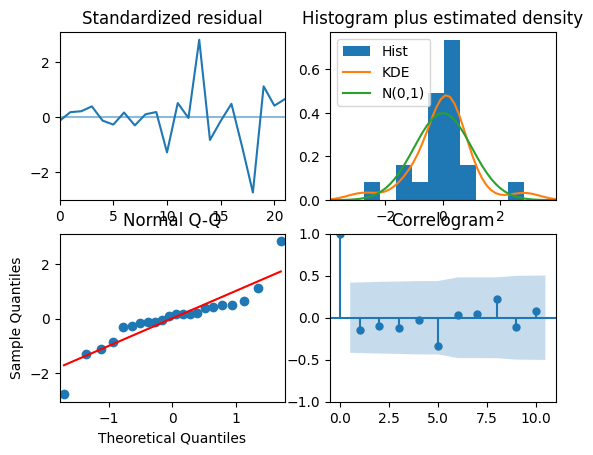

Best Model: ARIMA(2, 2, 0)


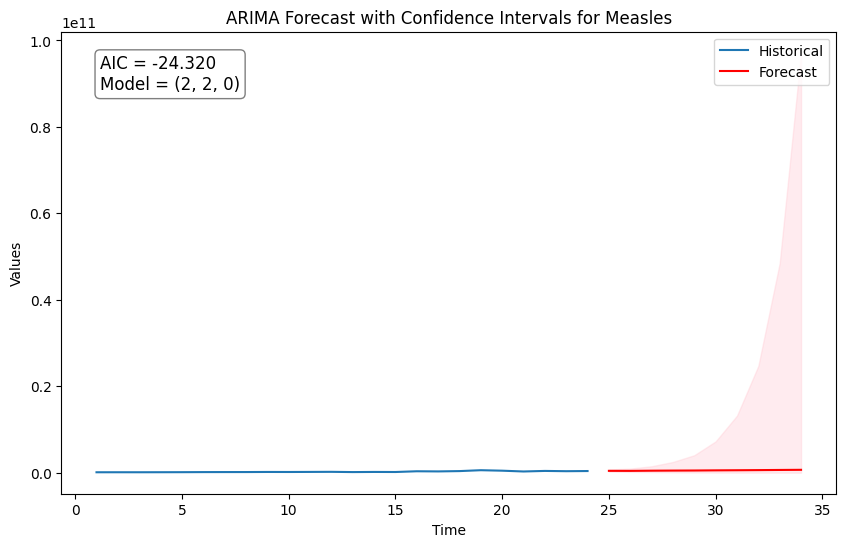

In [81]:
# Assuming 'data' is your DataFrame with the actual data

# fitted_dfs = {}
# forecast_dfs = {}
confidence_dfs = {}
# AIC_scores = {}
# exclude_columns = ['Measles', 'PCV', 'OPV', 'HPV', 'IPV', 'MR', 'MMR', 'Rota', 'TT', 'Td', 'DT', 'DTwP-Hib', 'HepB', 'Hib', 'DTwP-HepB-Hib']
exclude_columns = ['Mumps', 'Rubella', 'Pertussis', 'Hepatitis_B', 'Hib', 'Polio', 'HPV', 'Rotavirus', 'PCV', 'Diphtheria', 'Tetanus']
df_selected = data.drop(columns=exclude_columns)
df_selected = df_selected.iloc[13:]

for column in df_selected.columns[1:]:
    print(column)
    df_confidence = process_column_with_forecast(data[column], column, 'log10')
    # df_fitted, df_forecast, df_confidence, aic_value = process_column_with_forecast(data[column], column)
    # fitted_dfs[column] = df_fitted
    # forecast_dfs[column] = df_forecast
    confidence_dfs[column] = df_confidence
    # AIC_scores[column] = aic_value


0.01


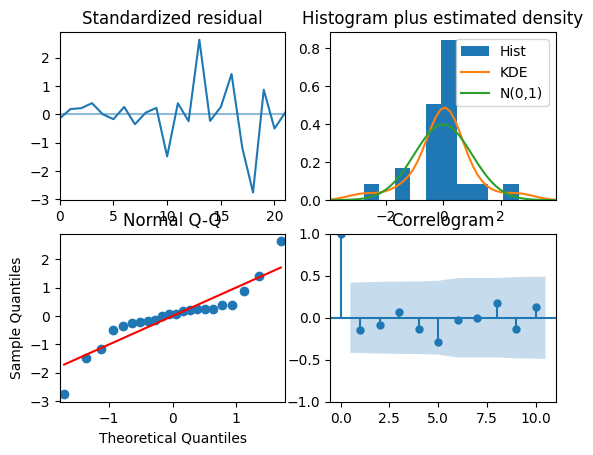

Best Model: ARIMA(1, 2, 1)


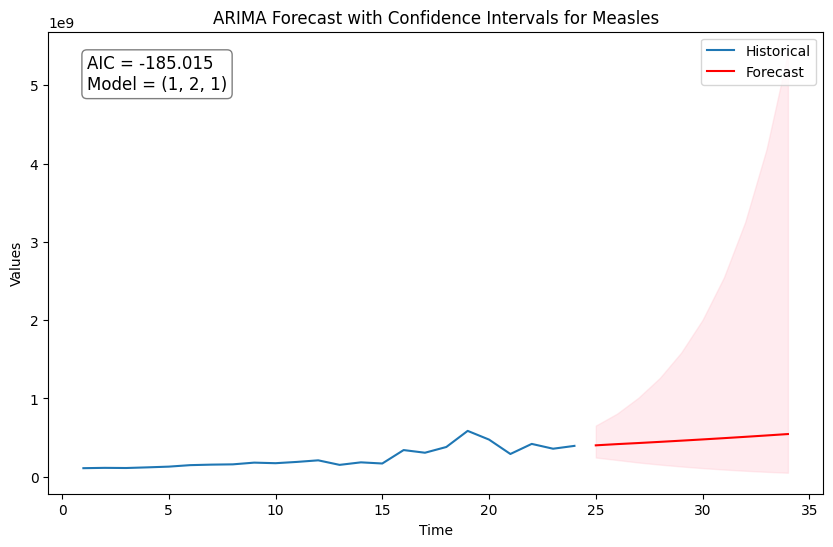

0.015


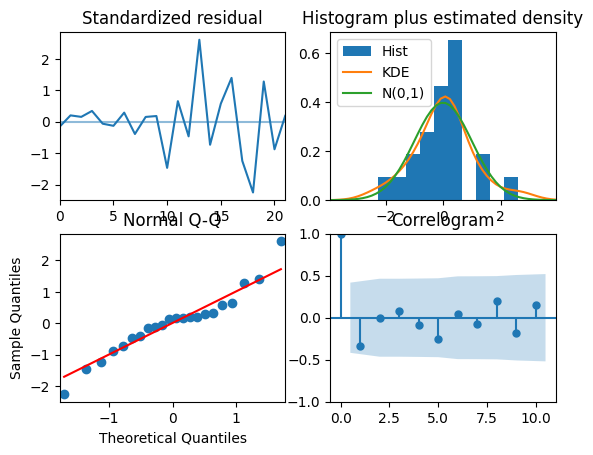

Best Model: ARIMA(0, 2, 1)


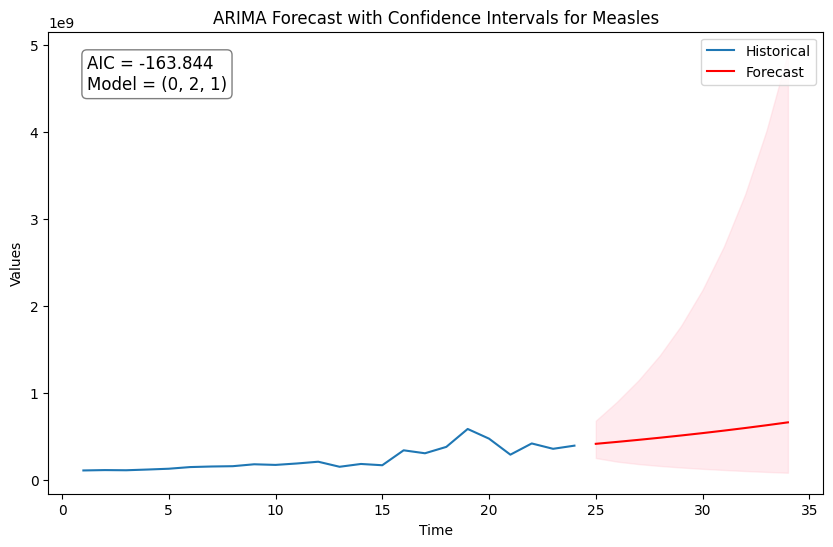

0.019999999999999997


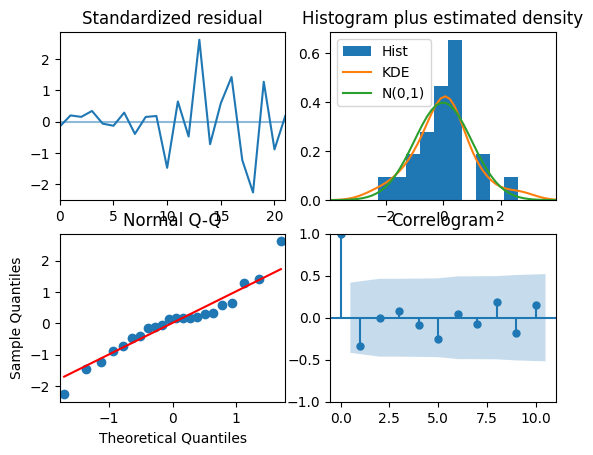

Best Model: ARIMA(0, 2, 1)


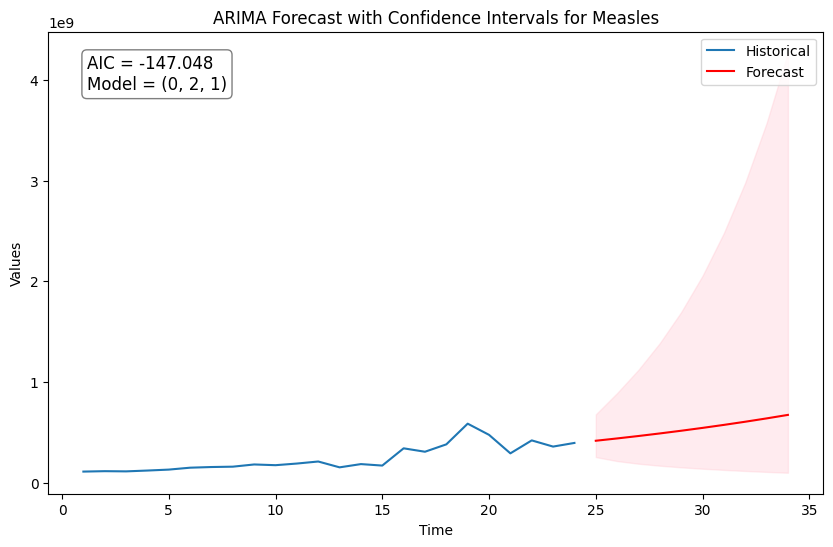

0.024999999999999998


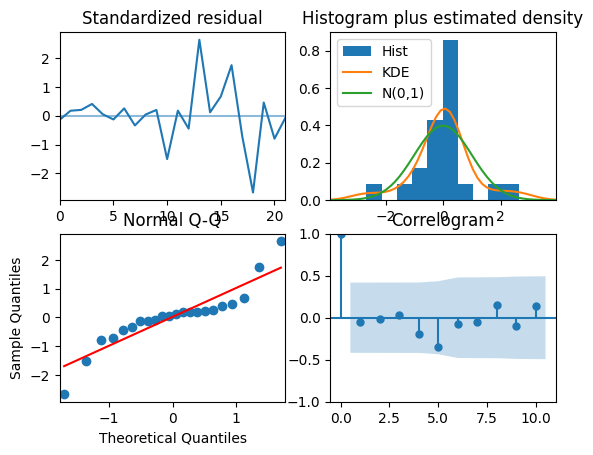

Best Model: ARIMA(0, 2, 2)


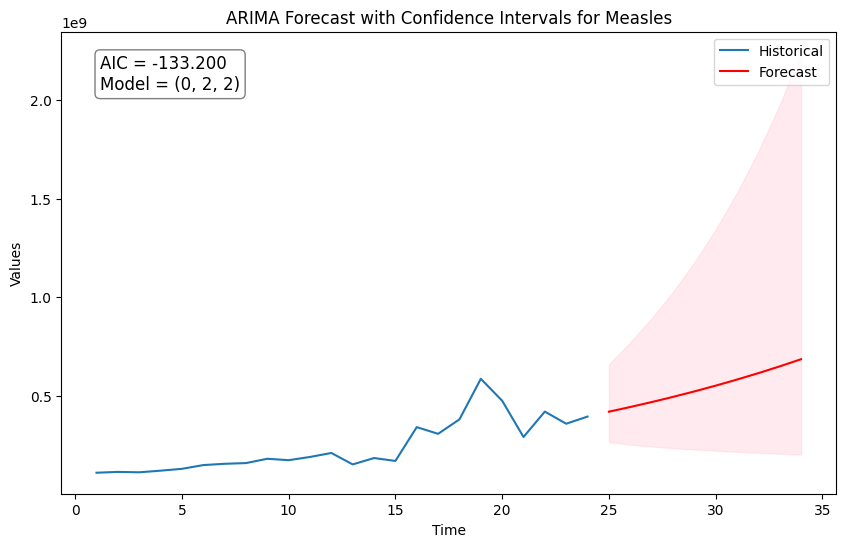

0.03


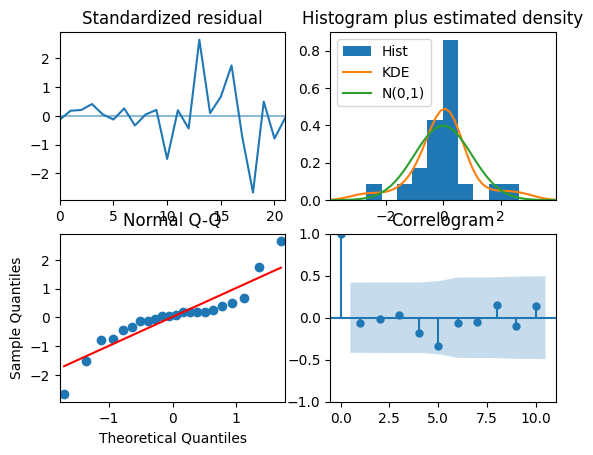

Best Model: ARIMA(0, 2, 2)


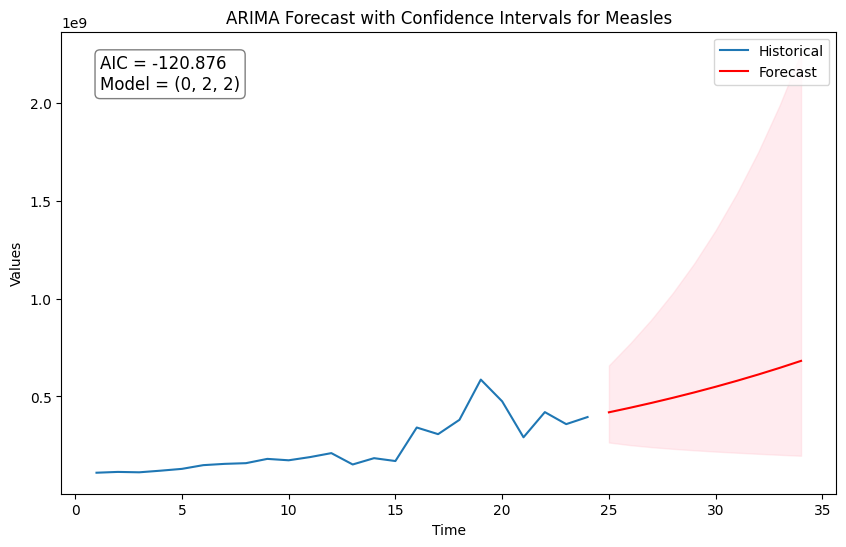

0.034999999999999996


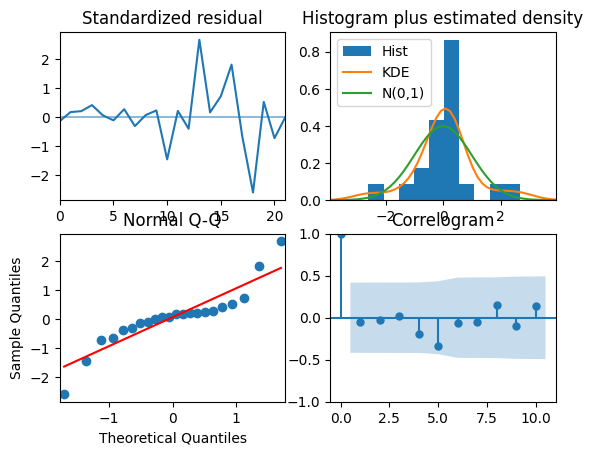

Best Model: ARIMA(0, 2, 2)


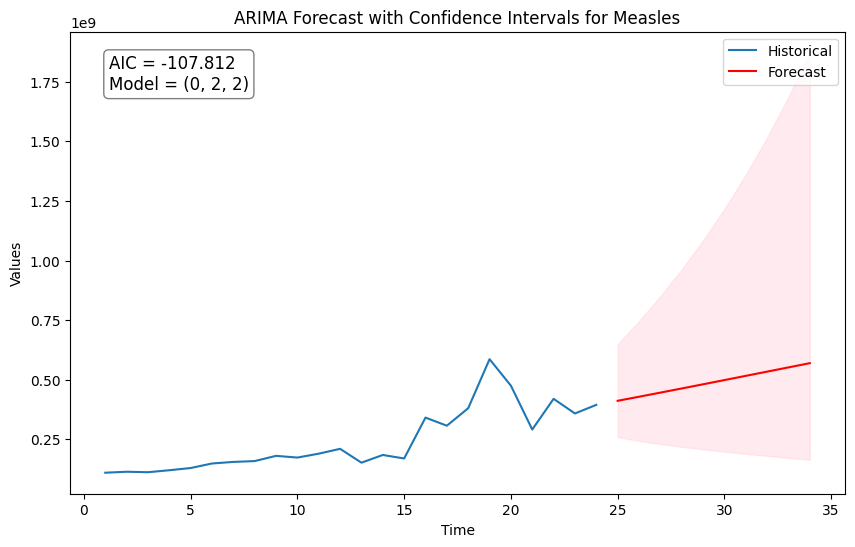

0.039999999999999994


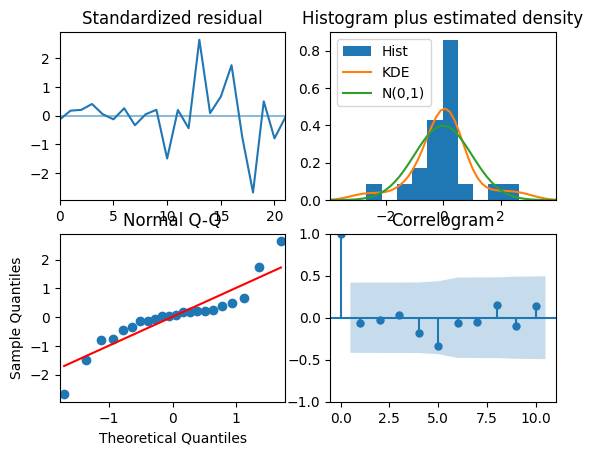

Best Model: ARIMA(0, 2, 2)


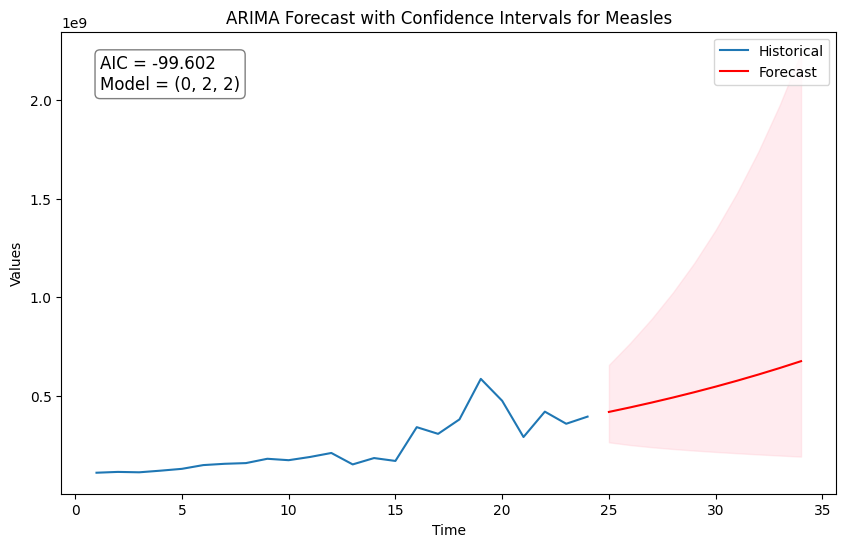

0.045


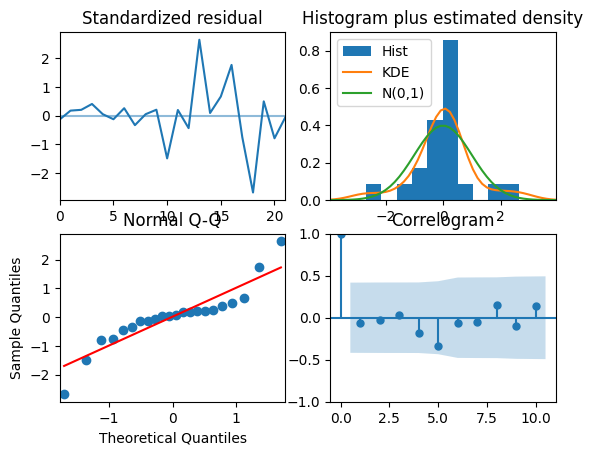

Best Model: ARIMA(0, 2, 2)


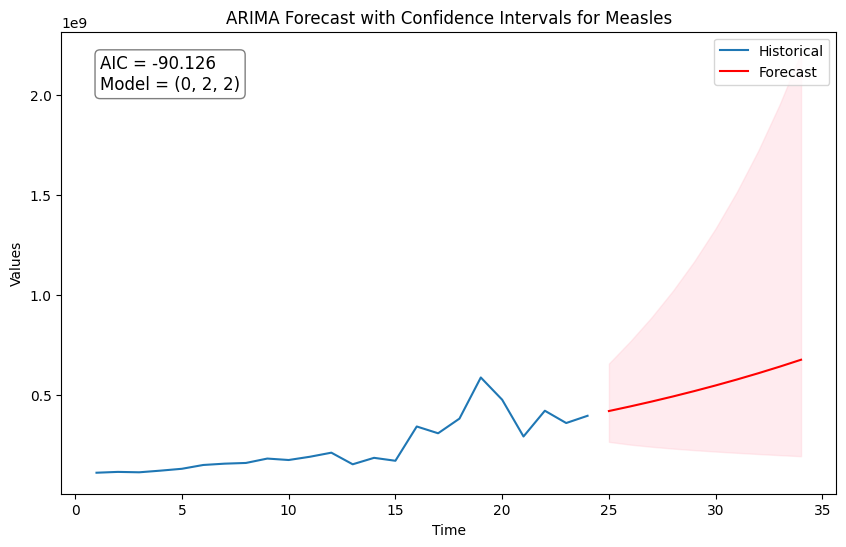

0.049999999999999996


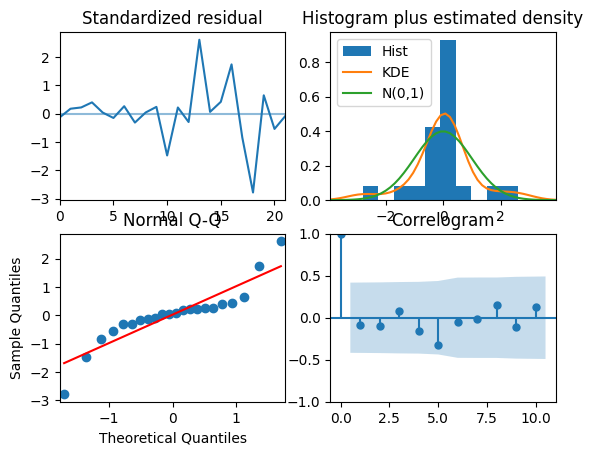

Best Model: ARIMA(1, 2, 1)


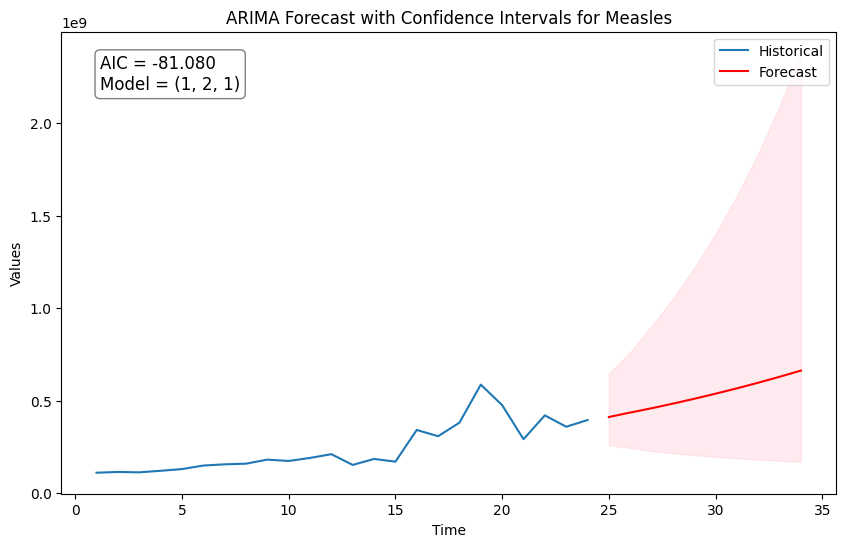

0.05499999999999999


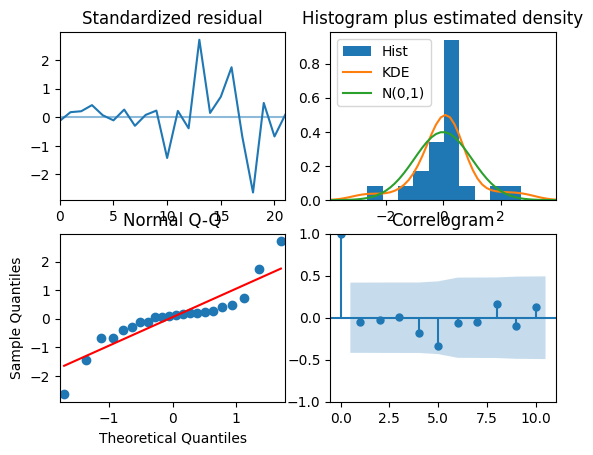

Best Model: ARIMA(2, 2, 1)


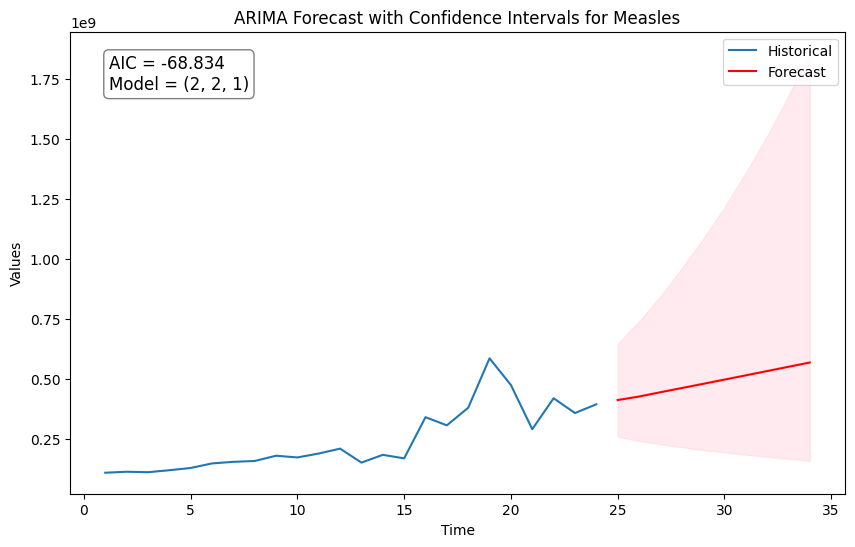

0.05999999999999999


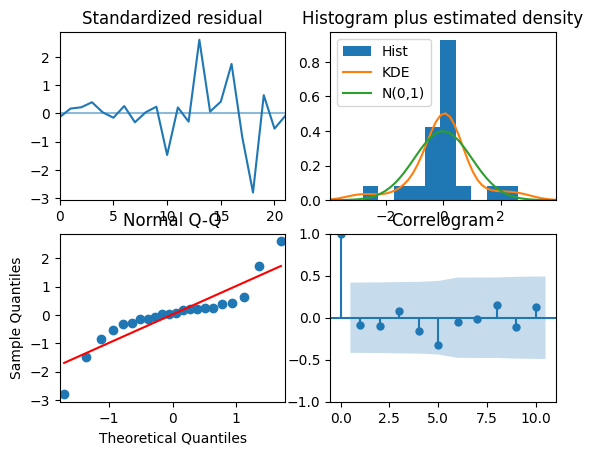

Best Model: ARIMA(1, 2, 1)


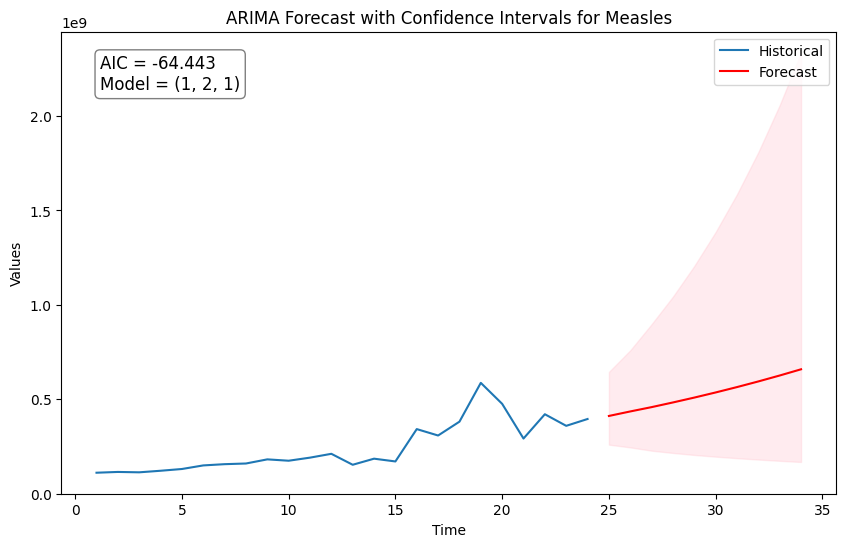

0.06499999999999999


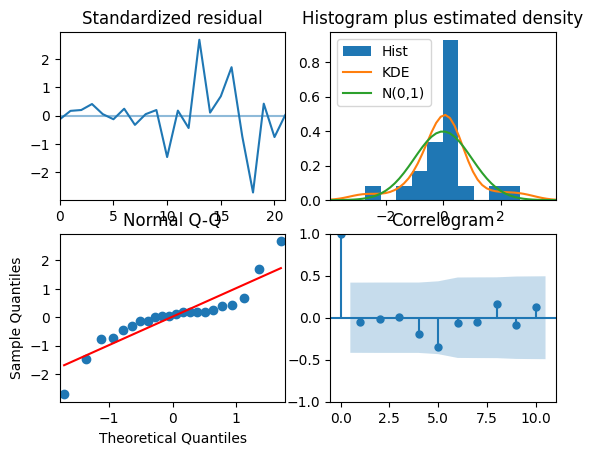

Best Model: ARIMA(2, 2, 1)


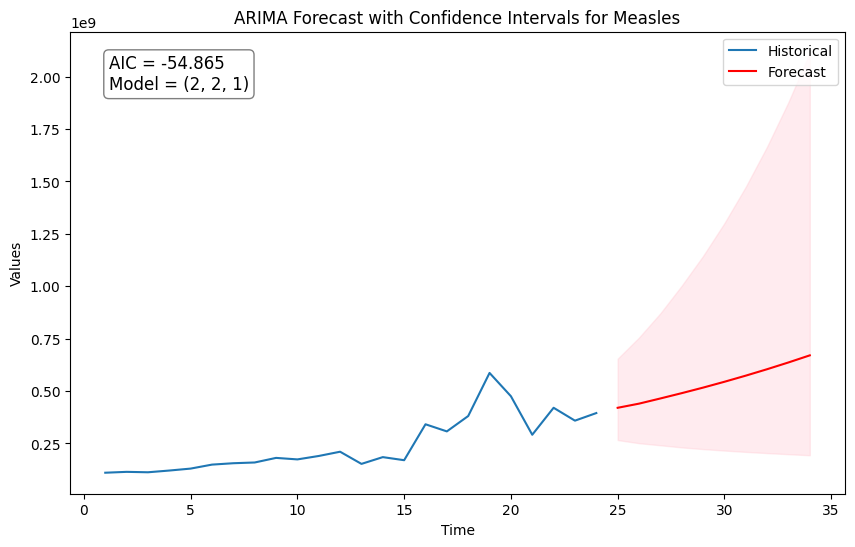

0.06999999999999999


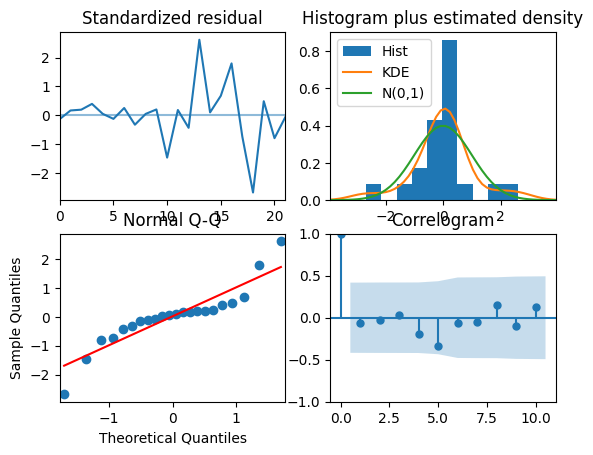

Best Model: ARIMA(0, 2, 2)


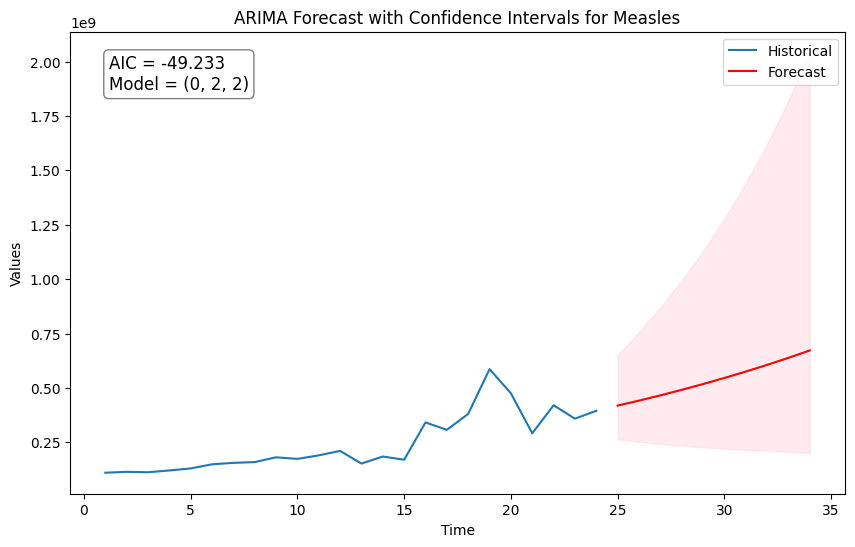

0.07499999999999998


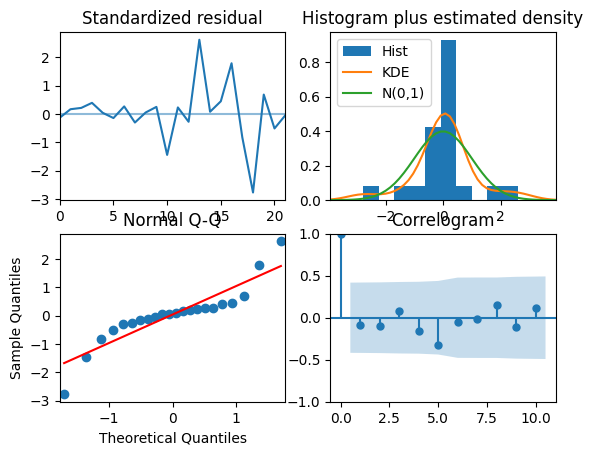

Best Model: ARIMA(1, 2, 1)


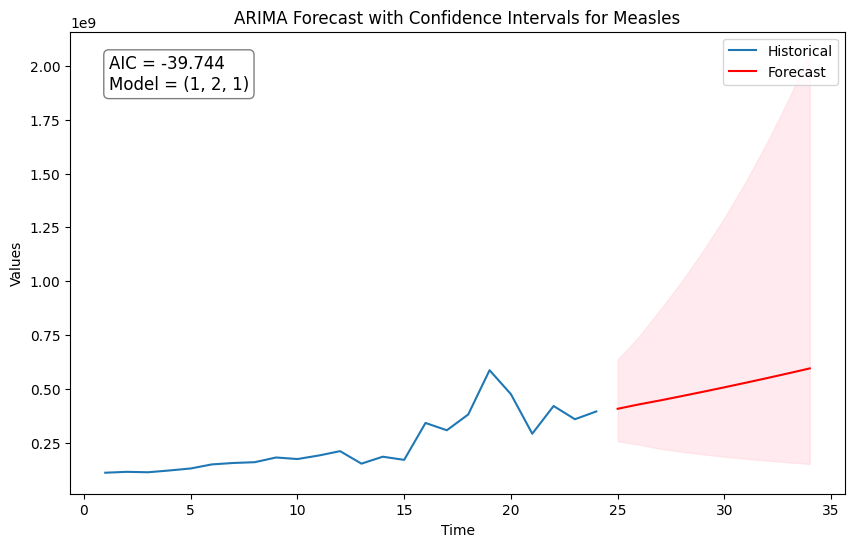

0.07999999999999999


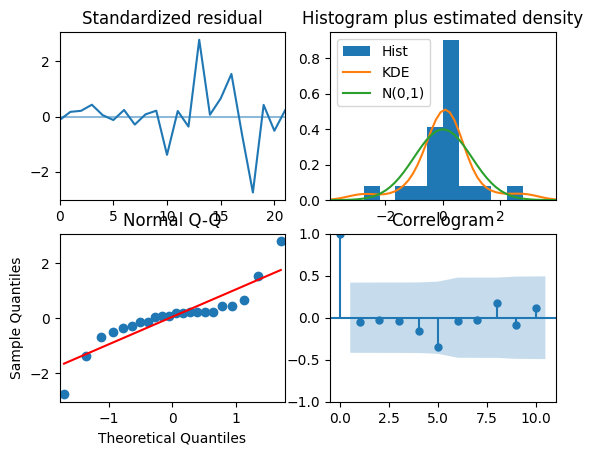

Best Model: ARIMA(3, 2, 1)


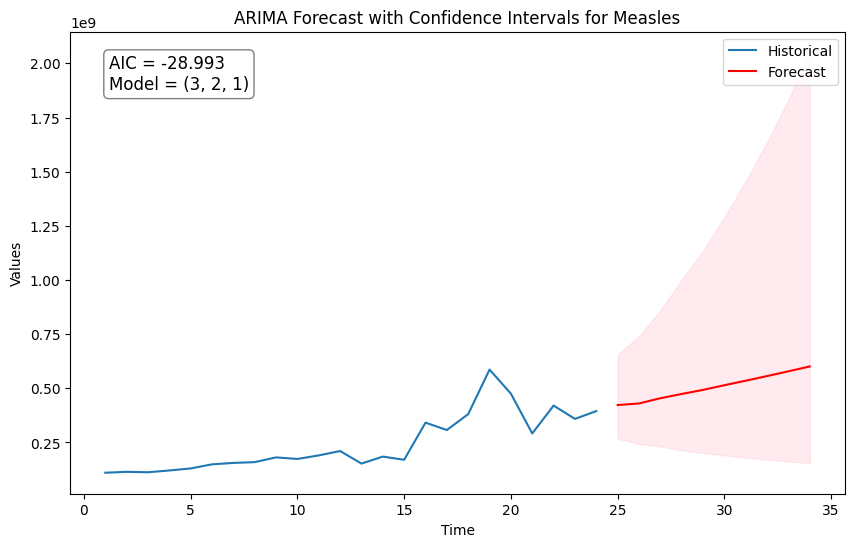

0.08499999999999998


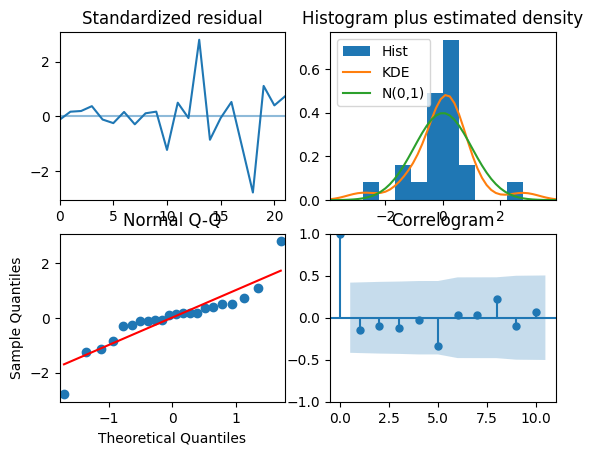

Best Model: ARIMA(2, 2, 0)


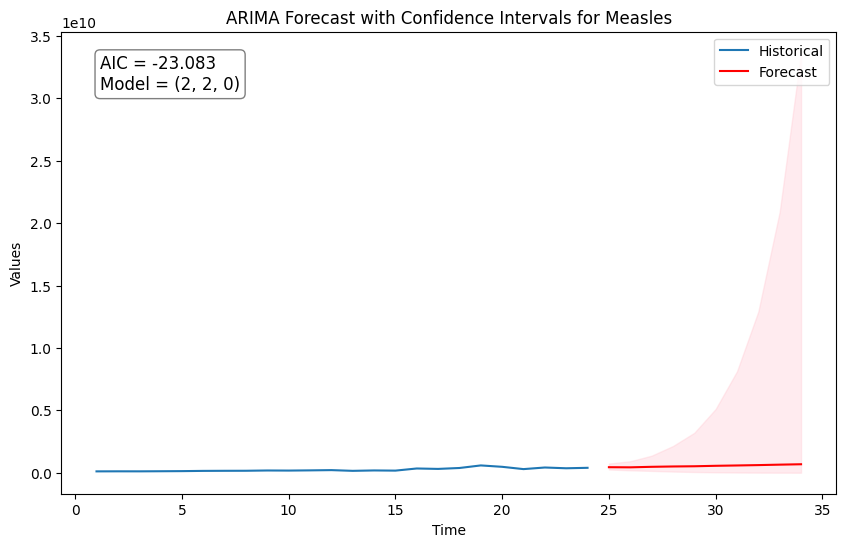

0.08999999999999998


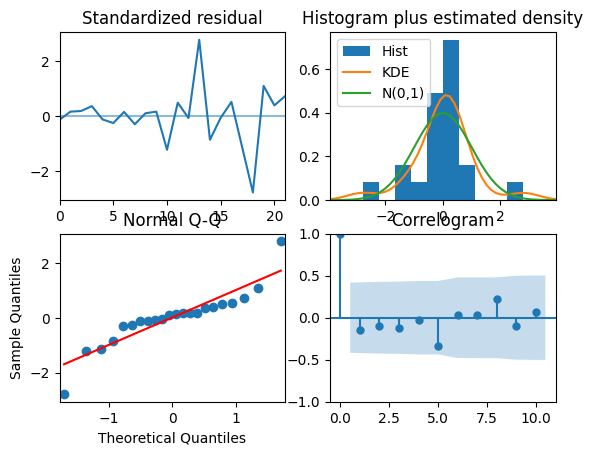

Best Model: ARIMA(2, 2, 0)


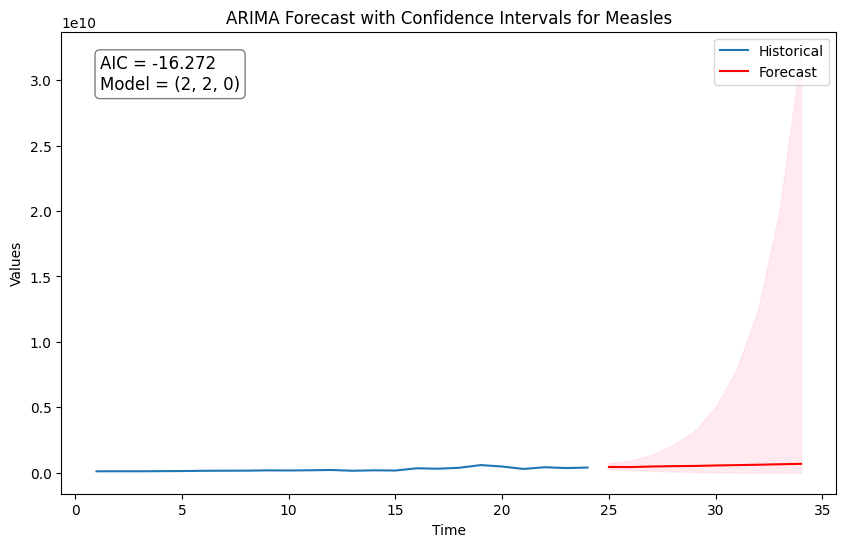

0.09499999999999999


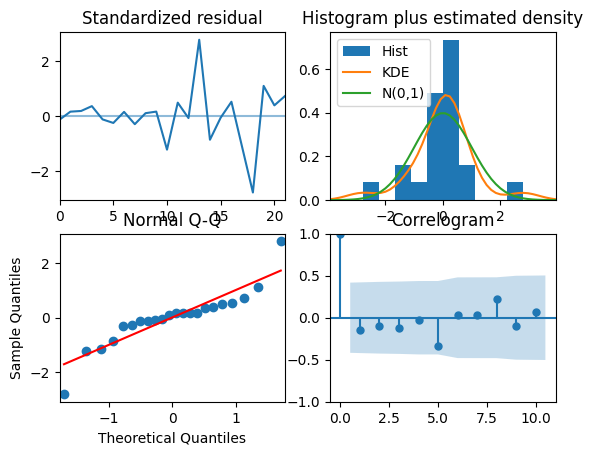

Best Model: ARIMA(2, 2, 0)


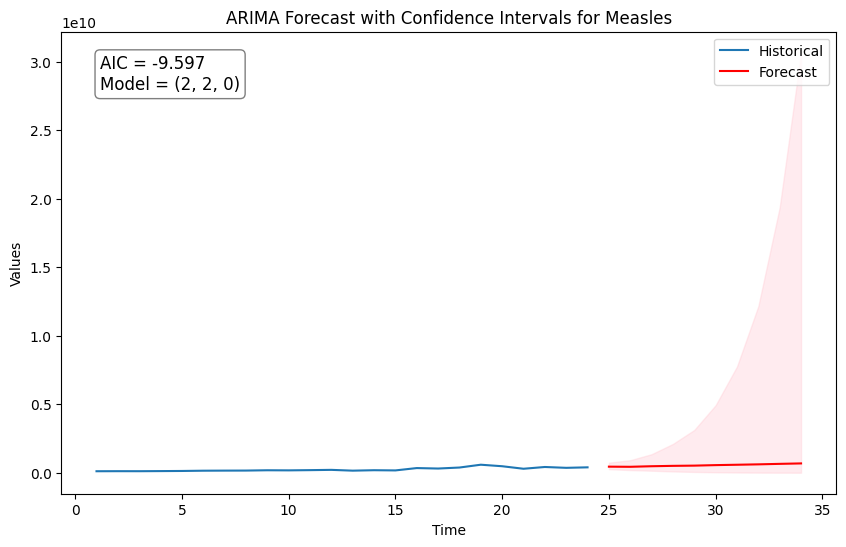

In [82]:
confidence_dfs = {}
AIC_scores = {}
exclude_columns = ['Mumps', 'Rubella', 'Pertussis', 'Hepatitis_B', 'Hib', 'Polio', 'HPV', 'Rotavirus', 'PCV', 'Diphtheria', 'Tetanus']
df_selected = data.drop(columns=exclude_columns)
df_selected = df_selected.iloc[13:]

for column in df_selected.columns[1:]:
    for power in np.arange(0.01,0.1, 0.005):
        print(power)
        df_confidence, aic_value = process_column_with_forecast(data[column], column, power)
        confidence_dfs[column] = df_confidence
        AIC_scores[power] = aic_value

In [ ]:
excel_path = 'antigen_CIs.xlsx'  # Specify your file path here

with pd.ExcelWriter(excel_path, engine='openpyxl', mode='a') as writer:
    # Iterate over the dictionary and write each DataFrame to a different sheet
    for sheet_name, df in confidence_dfs.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

In [ ]:
# Assuming 'data' is your DataFrame with the actual data

# fitted_dfs = {}
# forecast_dfs = {}
confidence_dfs = {}
# AIC_scores = {}
# exclude_columns = ['Diphtheria', 'Pertussis', 'Polio', 'Tetanus']
exclude_columns = ['Hib','HPV']
# df_selected = data.drop(columns=exclude_columns)

for column in data.loc[:, exclude_columns]:
    df_confidence = process_column_with_forecast(data[column], column, p=1)
    # df_fitted, df_forecast, df_confidence, aic_value = process_column_with_forecast(data[column], column)
    # fitted_dfs[column] = df_fitted
    # forecast_dfs[column] = df_forecast
    confidence_dfs[column] = df_confidence
    # AIC_scores[column] = aic_value

## Linear model

In [40]:
import pandas as pd

data = {
    "Year": [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "Diphtheria": [358960052.0, 354880969.0, 362257229.0, 402799889.0, 429658592.0, 474101067.0, 595266022.0, 606971011.0, 570550152.0, 619539916.0, 626455401.0]
}

df = pd.DataFrame(data)
df

,Year,Diphtheria
0,2013,358960052.0
1,2014,354880969.0
2,2015,362257229.0
3,2016,402799889.0
4,2017,429658592.0
5,2018,474101067.0
6,2019,595266022.0
7,2020,606971011.0
8,2021,570550152.0
9,2022,619539916.0


In [42]:
from sklearn.linear_model import LinearRegression
import numpy as np
import statsmodels.api as sm

# Independent variable
X = df['Year'].values.reshape(-1, 1)
# Dependent variable
y = df['Diphtheria'].values

# Fit the model
model = LinearRegression().fit(X, y)

# Get the predictions for the current data
predictions = model.predict(X)

# Add a constant for statsmodels
X_const = sm.add_constant(X)
model_stats = sm.OLS(y, X_const).fit()

# Calculate confidence intervals
predictions_stats = model_stats.get_prediction(X_const).summary_frame(alpha=0.05)


In [45]:
future_years = np.arange(2024, 2024 + 15).reshape(-1, 1)
future_years_const = sm.add_constant(future_years)

# Predictions for future years
future_predictions = model.predict(future_years)
future_predictions_stats = model_stats.get_prediction(future_years_const).summary_frame(alpha=0.05)


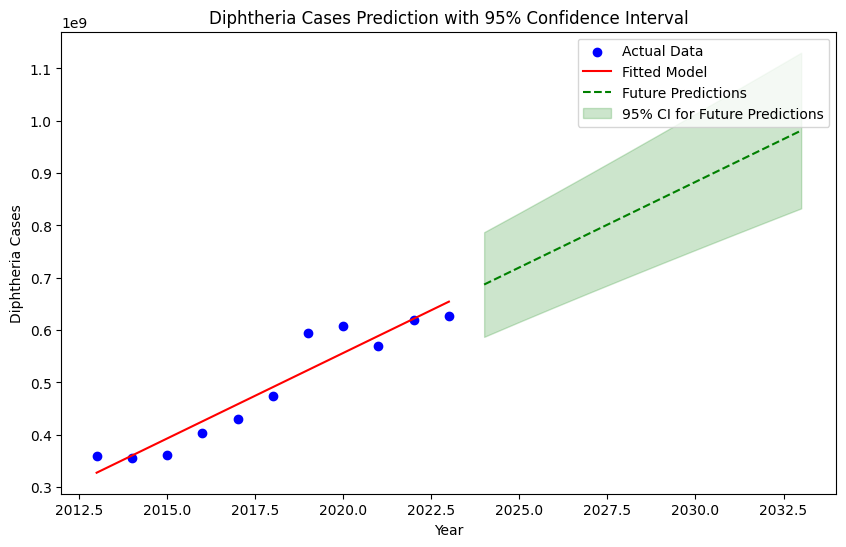

In [44]:
import matplotlib.pyplot as plt

# Plot the data and the model
plt.figure(figsize=(10, 6))
plt.scatter(df['Year'], df['Diphtheria'], color='blue', label='Actual Data')
plt.plot(df['Year'], predictions, color='red', label='Fitted Model')
plt.plot(future_years, future_predictions, color='green', linestyle='dashed', label='Future Predictions')

# Confidence intervals for the future predictions
plt.fill_between(future_years.flatten(),
                 future_predictions_stats['obs_ci_lower'],
                 future_predictions_stats['obs_ci_upper'],
                 color='green', alpha=0.2, label='95% CI for Future Predictions')

plt.xlabel('Year')
plt.ylabel('Diphtheria Cases')
plt.legend()
plt.title('Diphtheria Cases Prediction with 95% Confidence Interval')
plt.show()
